<a href="https://colab.research.google.com/github/oleksiikartashovde-glitch/Zero-point/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 МАТЕМАТИЧЕСКИЙ ОТЧЕТ СРАВНЕНИЯ ФИГУР (БЕЗ БИНАРИЗАЦИИ):
 • Чистое совпадение геометрии фигуры: 53.27%
 • Чистый процент брака (отклонения): 46.73% <--- теперь этот показатель соответствует сумме недостачи и избытка

КАРТА ГЕОМЕТРИЧЕСКИХ ОТКЛОНЕНИЙ:
🟩 Зеленый цвет — Тело фигуры (идеальное совпадение контуров)
🟥 Красный цвет — Дефект: Элементы фигуры, которых НЕ ХВАТАЕТ в 'fact'
🟦 Синий цвет — Дефект: Лишние элементы (ИЗБЫТОК / НАПЛЫВЫ) в 'fact'
------------------------------------------------------------


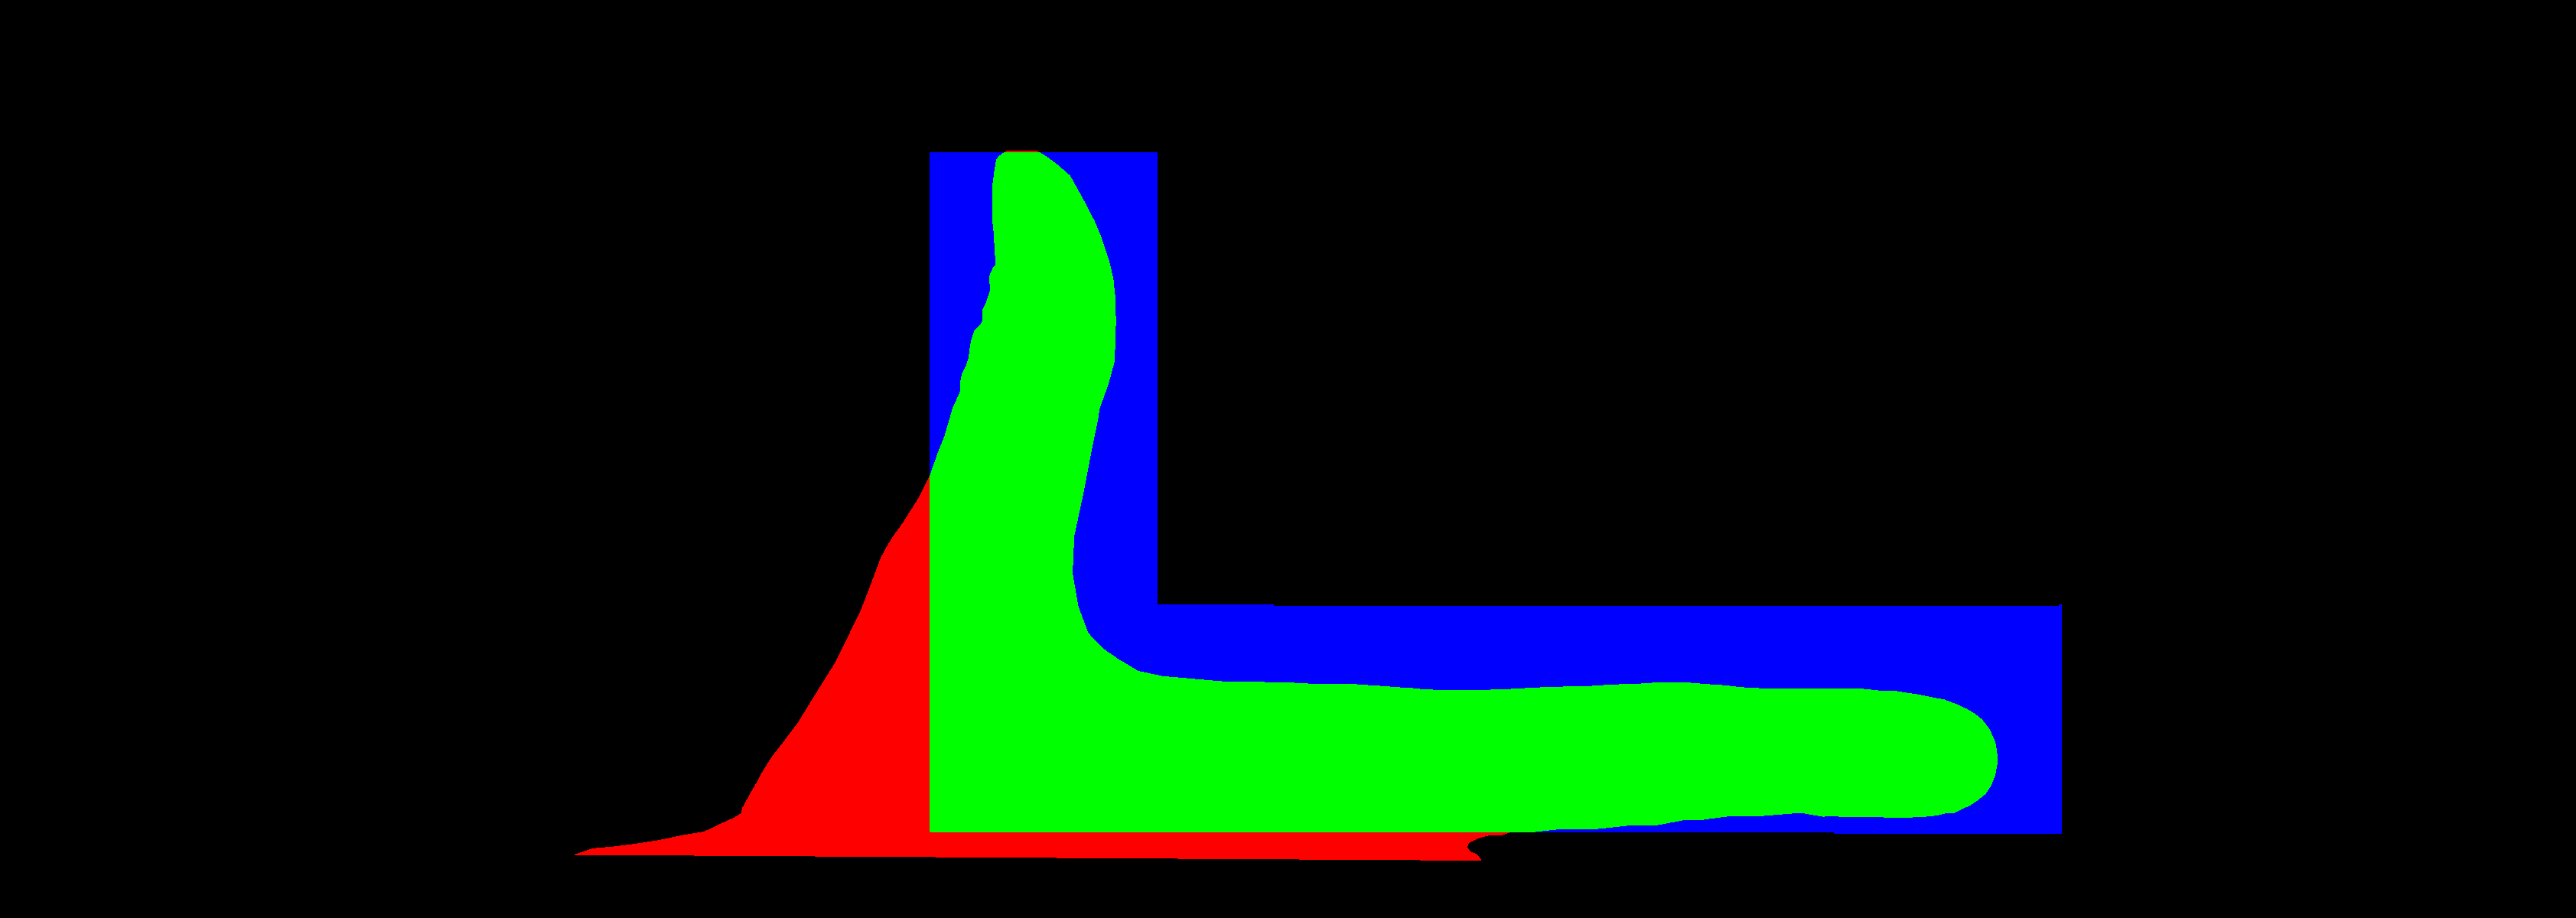


 ПРОФЕССИОНАЛЬНЫЙ АНАЛИЗ ГЕОМЕТРИЧЕСКОГО СОВПАДЕНИЯ
МЕТОДОЛОГИЯ ОЦЕНКИ:
Базовым критерием оценки выступает Общий процент геометрического совпадения
(метрика IoU / Коэффициент Жаккара). Это главный итоговый показатель,
который показывает, насколько формы идентичны в пространстве.

Формула расчета:
IoU = (Площадь пересечения / Площадь объединения) * 100%

--------------------------------------------------------------------------------
СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:
--------------------------------------------------------------------------------
[53.27%] КОЭФФИЦИЕНТ ЖАККАРА (IoU) | 🟩 Зеленая зона
         Общий процент идеального пространственного совпадения форм.

[13.57%] НЕДОСТАЧА МАТЕРИАЛА         | 🟥 Красная зона
         Показывает долю элементов эталона, которые факт «недовыполнил»
         или пропустил.

[33.16%] ИЗБЫТОК МАТЕРИАЛА           | 🟦 Синяя зона
         Показывает долю лишних наплывов или элементов факта,
         вылезших за пределы нормы.

----------------------------

In [18]:
# =====================================================================
# ШАГ 1: ИМПОРТ НЕОБХОДИМЫХ БИБЛИОТЕК
# =====================================================================
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# =====================================================================
# ШАГ 2: ЗАГРУЗКА ГОТОВЫХ ИЗОБРАЖЕНИЙ В СРЕДУ
# (Предполагается, что картинки уже бинаризованы: фигура=255, фон=0)
# =====================================================================
img_etalon = cv2.imread('etalon.png', 0)
img_fact = cv2.imread('fact.png', 0)

if img_etalon is None or img_fact is None:
    raise FileNotFoundError("Критическая ошибка: Проверьте, загружены ли 'etalon.png' и 'fact.png' в панель слева!")

# =====================================================================
# ШАГ 2.1: БИНАРИЗАЦИЯ ИЗОБРАЖЕНИЙ (если они не бинарные)
# (Преобразуем серые изображения в черно-белые, где фон=0, фигура=255)
# =====================================================================
# Используем THRESH_BINARY и THRESH_OTSU для автоматического определения порога
_, img_etalon_bin = cv2.threshold(img_etalon, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, img_fact_bin = cv2.threshold(img_fact, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Используем бинаризованные изображения для дальнейшей работы
img_etalon = img_etalon_bin
img_fact = img_fact_bin

# =====================================================================
# ШАГ 3: ВЫРАВНИВАНИЕ РАЗМЕРОВ
# =====================================================================
if img_etalon.shape != img_fact.shape:
    print(f"[ИНФО] Размеры не совпадают. Приводим картинку 'fact' к размеру эталона: {img_etalon.shape[1]}x{img_etalon.shape[0]} пикселей.")
    # Используем INTER_NEAREST, чтобы сохранить бинарность (только 0 и 255)
    img_fact = cv2.resize(img_fact, (img_etalon.shape[1], img_etalon.shape[0]), interpolation=cv2.INTER_NEAREST)

# =====================================================================
# ШАГ 4: ПОПИКСЕЛЬНЫЙ МАТЕМАТИЧЕСКИЙ АНАЛИЗ (МЕТРИКА IoU)
# =====================================================================
# Находим пересечение и объединение напрямую по матрицам
intersection = cv2.bitwise_and(img_etalon, img_fact)
union = cv2.bitwise_or(img_etalon, img_fact)

# Считаем площади (количество белых пикселей фигуры)
area_intersection = np.sum(intersection == 255)
area_union = np.sum(union == 255)

# Считаем площади недостачи и избытка
area_miss = np.sum((img_etalon == 255) & (img_fact == 0))
area_excess = np.sum((img_etalon == 0) & (img_fact == 255))

if area_union == 0:
    match_percentage = 0.0
    miss_percentage = 0.0
    excess_percentage = 0.0
    total_defect_percentage = 0.0
else:
    # Calculate raw percentages
    miss_pct_raw = (area_miss / area_union) * 100
    excess_pct_raw = (area_excess / area_union) * 100

    # Round individual defect percentages for display
    miss_percentage = round(miss_pct_raw, 2)
    excess_percentage = round(excess_pct_raw, 2)

    # Calculate total defect percentage as sum of rounded individual defects
    total_defect_percentage = round(miss_percentage + excess_percentage, 2)

    # Calculate match percentage to ensure it complements total defect to 100%
    match_percentage = round(100.00 - total_defect_percentage, 2)

# Set difference_percentage equal to total_defect_percentage for consistency
difference_percentage = total_defect_percentage

print("\n" + "="*60)
print(f" МАТЕМАТИЧЕСКИЙ ОТЧЕТ СРАВНЕНИЯ ФИГУР (БЕЗ БИНАРИЗАЦИИ):")
print(f" • Чистое совпадение геометрии фигуры: {match_percentage:.2f}%")
print(f" • Чистый процент брака (отклонения): {difference_percentage:.2f}% <--- теперь этот показатель соответствует сумме недостачи и избытка")
print("="*60 + "\n")

# =====================================================================
# ШАГ 5: НАГЛЯДНАЯ ВИЗУАЛИЗАЦИЯ ДЕФЕКТОВ ФИГУРЫ
# =====================================================================
height, width = img_etalon.shape
color_map = np.zeros((height, width, 3), dtype=np.uint8)

# А. Зона идеального совпадения самой фигуры — красим в зеленый
color_map[intersection == 255] = [0, 255, 0]

# Б. НЕДОСТАЧА МАТЕРИАЛА (В эталоне 255, в факте 0). Красим в КРАСНЫЙ.
color_map[(img_etalon == 255) & (img_fact == 0)] = [0, 0, 255]

# В. ИЗБЫТОК МАТЕРИАЛА (В эталоне 0, в факте 255). Красим в СИНИЙ.
color_map[(img_etalon == 0) & (img_fact == 255)] = [255, 0, 0]

print("КАРТА ГЕОМЕТРИЧЕСКИХ ОТКЛОНЕНИЙ:")
print("🟩 Зеленый цвет — Тело фигуры (идеальное совпадение контуров)")
print("🟥 Красный цвет — Дефект: Элементы фигуры, которых НЕ ХВАТАЕТ в 'fact'")
print("🟦 Синий цвет — Дефект: Лишние элементы (ИЗБЫТОК / НАПЛЫВЫ) в 'fact'")
print("-" * 60)

cv2_imshow(color_map)
# =====================================================================
# ДОПОЛНИТЕЛЬНЫЙ ШАГ: ПРОФЕССИОНАЛЬНЫЙ ОТЧЕТ (ВСТАВИТЬ В КОНЕЦ)
# =====================================================================
# miss_percentage, excess_percentage, total_defect_percentage уже рассчитаны в ШАГ 4

print("\n" + "=" * 80)
print(" ПРОФЕССИОНАЛЬНЫЙ АНАЛИЗ ГЕОМЕТРИЧЕСКОГО СОВПАДЕНИЯ")
print("=" * 80)
print("МЕТОДОЛОГИЯ ОЦЕНКИ:")
print("Базовым критерием оценки выступает Общий процент геометрического совпадения")
print("(метрика IoU / Коэффициент Жаккара). Это главный итоговый показатель,")
print("который показывает, насколько формы идентичны в пространстве.\n")
print("Формула расчета:")
print("IoU = (Площадь пересечения / Площадь объединения) * 100%\n")

print("-" * 80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print("-" * 80)

print(f"[{match_percentage:05.2f}%] КОЭФФИЦИЕНТ ЖАККАРА (IoU) | 🟩 Зеленая зона")
print("         Общий процент идеального пространственного совпадения форм.\n")

print(f"[{miss_percentage:05.2f}%] НЕДОСТАЧА МАТЕРИАЛА         | 🟥 Красная зона")
print("         Показывает долю элементов эталона, которые факт «недовыполнил»")
print("         или пропустил.\n")

print(f"[{excess_percentage:05.2f}%] ИЗБЫТОК МАТЕРИАЛА           | 🟦 Синяя зона")
print("         Показывает долю лишних наплывов или элементов факта,")
print("         вылезших за пределы нормы.\n")

print("-" * 80)
print("РЕЗЮМЕ ОТКЛОНЕНИЙ:")
print(f"Общий уровень геометрического брака составляет {total_defect_percentage:.2f}%.")

if excess_percentage > miss_percentage:
    print("Детальный разбор показывает, что деформация фигуры-факта носит преимущественно")
    print(f"экстенсивный характер: доля избыточных наплывов ({excess_percentage:.2f}%) превышает")
    print(f"долю пропущенных участков ({miss_percentage:.2f}%).")
elif miss_percentage > excess_percentage:
    print("Детальный разбор показывает, что деформация фигуры-факта носит преимущественно")
    print(f"редуктивный характер: доля пропущенных участков ({miss_percentage:.2f}%) превышает")
    print(f"долю избыточных наплывов ({excess_percentage:.2f}%).")
else:
    print("Детальный разбор показывает абсолютно сбалансированное распределение дефектов.")

print("=" * 80 + "\n")